2025-08-24 20:46:41.302981: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-24 20:46:41.586323: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-24 20:46:47.148817: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.



Training with Dropout regularization...


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-24 20:46:49.849269: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-08-24 20:46:49.990706: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.
2025-08-24 20:46:53.706688: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37632000 exceeds 10% of free system memory.
2025-08-24 20:47:25.890129: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.


Dropout Test Accuracy: 0.9808

Training with L1 regularization...


2025-08-24 20:47:26.536279: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.
2025-08-24 20:47:29.816529: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37632000 exceeds 10% of free system memory.


L1 Test Accuracy: 0.1135

Training with L2 regularization...
L2 Test Accuracy: 0.1135


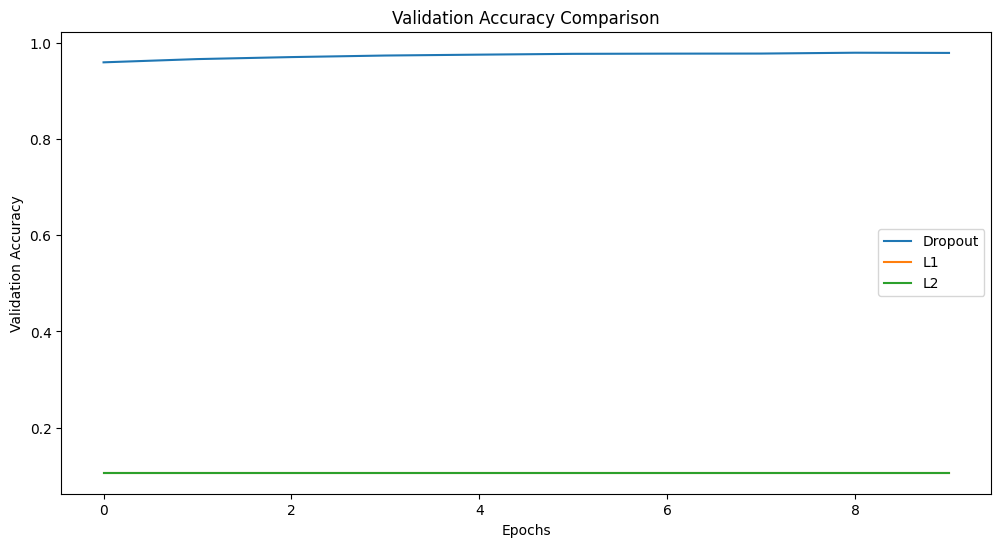

In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28*28).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28*28).astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_model(reg_type=None):
    if reg_type == "L1":
        reg = regularizers.l1(0.001)
    elif reg_type == "L2":
        reg = regularizers.l2(0.001)
    else:
        reg = None

    model = Sequential([
        Dense(512, activation="relu", input_shape=(784,), kernel_regularizer=reg),
        Dropout(0.5) if reg_type == "Dropout" else Dense(0),  # only add dropout layer in dropout case
        Dense(256, activation="relu", kernel_regularizer=reg),
        Dense(10, activation="softmax")
    ])

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Train models
histories = {}
for reg_type in ["Dropout", "L1", "L2"]:
    print(f"\nTraining with {reg_type} regularization...")
    model = build_model(reg_type)
    history = model.fit(X_train, y_train,
                        validation_split=0.2,
                        epochs=10, batch_size=128,
                        verbose=0)
    histories[reg_type] = history

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{reg_type} Test Accuracy: {test_acc:.4f}")

# Plot training history
plt.figure(figsize=(12,6))
for reg_type, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'{reg_type}')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()
